In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import json
import torch
import wandb

with open('../data/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

CLASSES = config['classes']

os.makedirs('../results/final_report', exist_ok=True)

print("✅ Setup done!")

✅ Setup done!


In [2]:
wandb.init(
    project='xray-classification',
    name='07-final-report',
    config={
        'pipeline': 'Segmentation→Classification→Explainability',
        'dataset': 'NIH ChestXray14',
        'total_images': 112120,
        'num_classes': 15
    }
)
print('✅ Wandb initialized!')

wandb: Currently logged in as: chandinigunna06 (chandinigunna06-iiest-shibpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Wandb initialized!


In [3]:
# Classification AUC
clf_scores = {
    'ResNet50':     0.6874,
    'DenseNet121':  0.7501,
    'EfficientNet': 0.7566,
    'VGG16':        0.7587,
    'ViT':          0.7584,
    'ConvNeXt':     0.7430
}

# Segmentation Dice
seg_scores = {
    'UNet':          97.14,
    'UNet++':        97.65,
    'Attention UNet':97.03,
    'DeepLabV3+':    97.17
}

# GradCAM IoU
gradcam_scores = {
    'ResNet50':     0.0527,
    'DenseNet121':  0.1441,
    'EfficientNet': 0.0387,
    'VGG16':        0.1216,
    'ConvNeXt':     0.1525,
    'ViT':          0.0
}

# GradCAM++ IoU
gradcampp_scores = {
    'ResNet50':     0.1199,
    'DenseNet121':  0.1722,
    'EfficientNet': 0.1281,
    'VGG16':        0.1806,
    'ConvNeXt':     0.1480,
    'ViT':          0.0
}

# Attention Rollout
attention_scores = {
    'ResNet50':     0.0,
    'DenseNet121':  0.0,
    'EfficientNet': 0.0,
    'VGG16':        0.0,
    'ConvNeXt':     0.0,
    'ViT':          0.1246
}

models     = list(clf_scores.keys())
best_seg   = max(seg_scores,   key=seg_scores.get)
best_clf   = max(clf_scores,   key=clf_scores.get)

print('✅ All results loaded!')
print(f'Best Seg : {best_seg}')
print(f'Best Clf : {best_clf}')


✅ All results loaded!
Best Seg : UNet++
Best Clf : VGG16


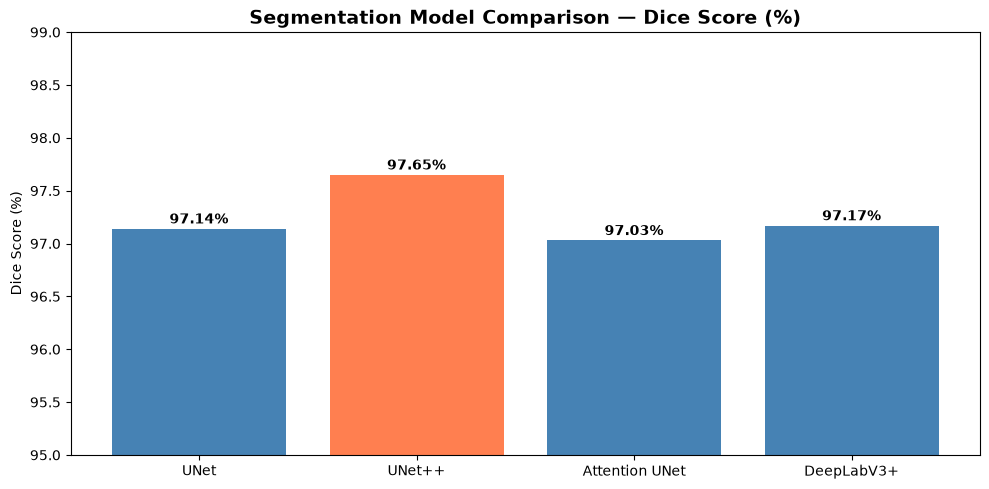

✅ Saved!


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['coral' if k == best_seg else 'steelblue' for k in seg_scores.keys()]
bars   = ax.bar(seg_scores.keys(), seg_scores.values(), color=colors)
ax.set_title('Segmentation Model Comparison — Dice Score (%)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Dice Score (%)')
ax.set_ylim(95, 99)
for bar, val in zip(bars, seg_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/final_report/01_segmentation.png', dpi=150)
plt.show()
wandb.log({'segmentation_chart': wandb.Image('../results/final_report/01_segmentation.png')})
print('✅ Saved!')

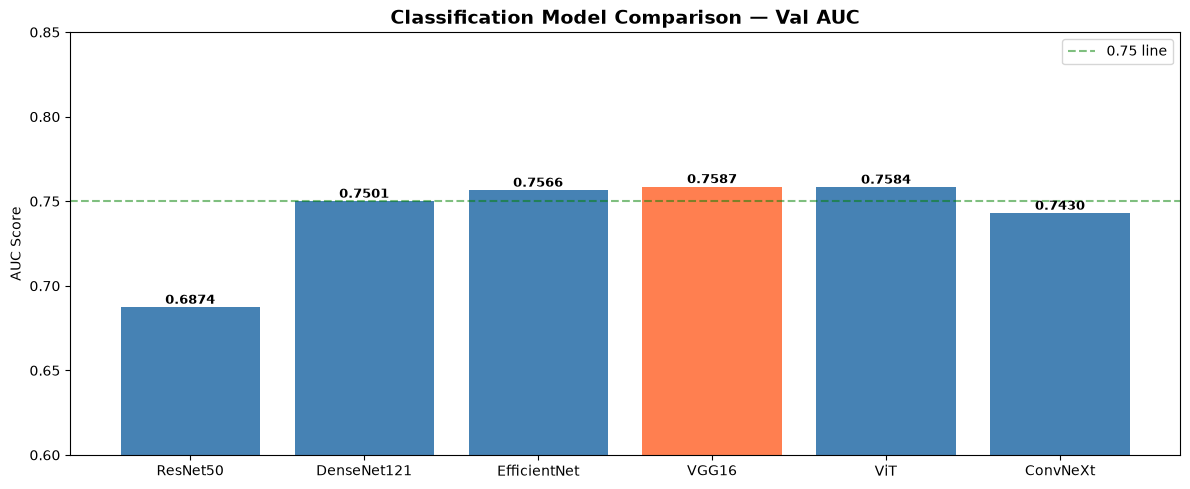

✅ Saved!


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['coral' if k == best_clf else 'steelblue' for k in clf_scores.keys()]
bars    = ax.bar(clf_scores.keys(), clf_scores.values(), color=colors)
ax.set_title('Classification Model Comparison — Val AUC',
             fontsize=14, fontweight='bold')
ax.set_ylabel('AUC Score')
ax.set_ylim(0.6, 0.85)
ax.axhline(y=0.75, color='green', linestyle='--', alpha=0.5, label='0.75 line')
ax.legend()
for bar, val in zip(bars, clf_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/final_report/02_classification.png', dpi=150)
plt.show()
wandb.log({'classification_chart': wandb.Image('../results/final_report/02_classification.png')})
print('✅ Saved!')

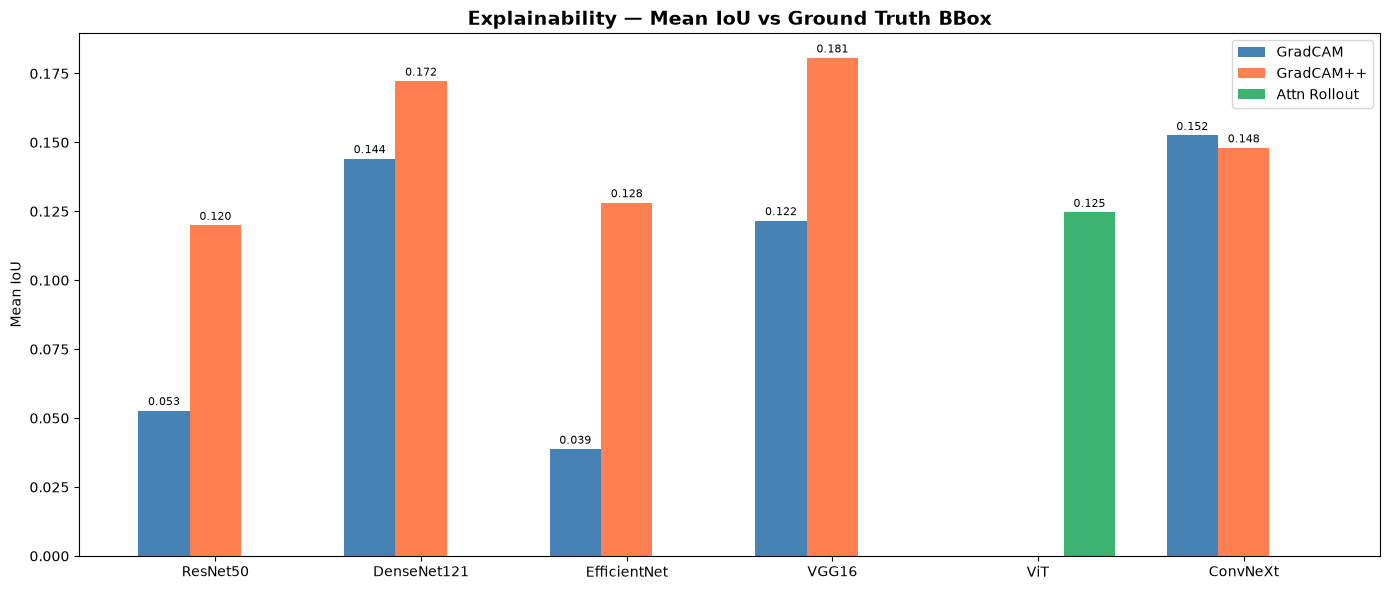

✅ Saved!


In [6]:
x     = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, [gradcam_scores[m]   for m in models],
            width, label='GradCAM',    color='steelblue')
b2 = ax.bar(x,          [gradcampp_scores[m] for m in models],
            width, label='GradCAM++',  color='coral')
b3 = ax.bar(x + width,  [attention_scores[m] for m in models],
            width, label='Attn Rollout', color='mediumseagreen')

ax.set_title('Explainability — Mean IoU vs Ground Truth BBox',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Mean IoU')
ax.legend()

for bar in list(b1) + list(b2) + list(b3):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/final_report/03_explainability.png', dpi=150)
plt.show()
wandb.log({'explainability_chart': wandb.Image('../results/final_report/03_explainability.png')})
print('✅ Saved!')

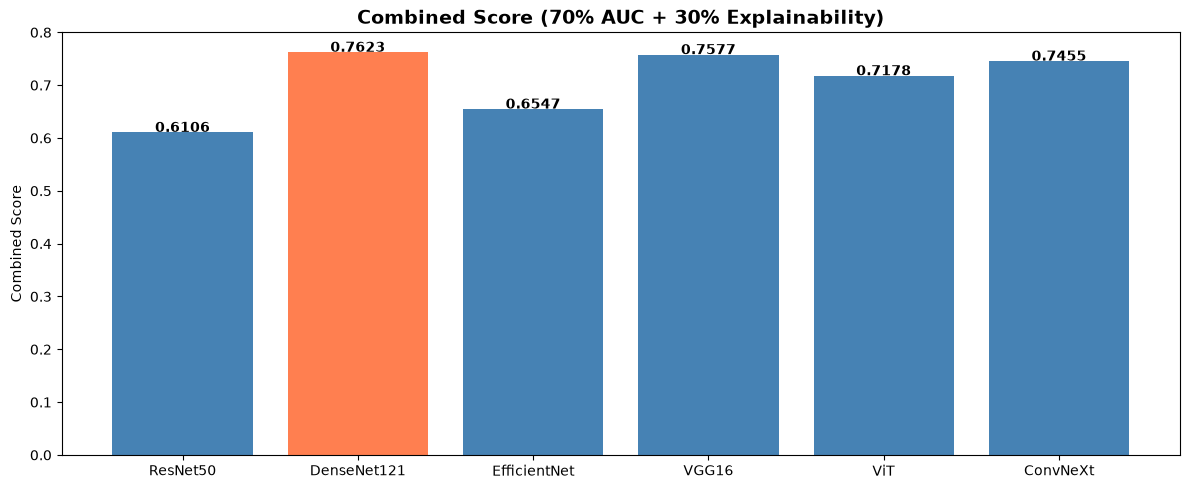

🏆 Best Overall: DenseNet121 (0.7623)


In [7]:
combined = {}
for m in models:
    auc        = clf_scores[m]
    xai_list   = [s for s in [gradcam_scores[m],
                               gradcampp_scores[m],
                               attention_scores[m]] if s > 0]
    avg_xai    = np.mean(xai_list) if xai_list else 0
    combined[m] = round(0.7 * auc + 0.3 * avg_xai * 5, 4)

best_overall = max(combined, key=combined.get)

fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['coral' if k == best_overall else 'steelblue' for k in combined.keys()]
bars    = ax.bar(combined.keys(), combined.values(), color=colors)
ax.set_title('Combined Score (70% AUC + 30% Explainability)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Combined Score')
for bar, val in zip(bars, combined.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/final_report/04_combined.png', dpi=150)
plt.show()
wandb.log({'combined_chart': wandb.Image('../results/final_report/04_combined.png')})
print(f'🏆 Best Overall: {best_overall} ({combined[best_overall]:.4f})')

In [8]:
rows = []
for m in models:
    xai_list = [s for s in [gradcam_scores[m],
                             gradcampp_scores[m],
                             attention_scores[m]] if s > 0]
    avg_xai  = round(np.mean(xai_list), 4) if xai_list else 0
    rows.append({
        'Model':          m,
        'Val AUC':        clf_scores[m],
        'GradCAM IoU':    gradcam_scores[m],
        'GradCAM++ IoU':  gradcampp_scores[m],
        'Attn IoU':       attention_scores[m],
        'Avg XAI IoU':    avg_xai,
        'Combined Score': combined[m]
    })

summary_df = pd.DataFrame(rows).sort_values('Combined Score', ascending=False)
summary_df.to_csv('../results/final_report/summary_table.csv', index=False)

print('='*70)
print('  FINAL SUMMARY TABLE')
print('='*70)
print(summary_df.to_string(index=False))

# Log table to wandb
wandb.log({'summary_table': wandb.Table(dataframe=summary_df)})
print('\n✅ Summary table saved!')

  FINAL SUMMARY TABLE
       Model  Val AUC  GradCAM IoU  GradCAM++ IoU  Attn IoU  Avg XAI IoU  Combined Score
 DenseNet121   0.7501       0.1441         0.1722    0.0000       0.1582          0.7623
       VGG16   0.7587       0.1216         0.1806    0.0000       0.1511          0.7577
    ConvNeXt   0.7430       0.1525         0.1480    0.0000       0.1502          0.7455
         ViT   0.7584       0.0000         0.0000    0.1246       0.1246          0.7178
EfficientNet   0.7566       0.0387         0.1281    0.0000       0.0834          0.6547
    ResNet50   0.6874       0.0527         0.1199    0.0000       0.0863          0.6106

✅ Summary table saved!
